<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Solution to Fool a CNN 
In this notebook you will *fool* a neural network by creating an image that looks like a **cat** *to a human beholder* but the neural network predicts a probability of almost 1 that the image is of a **plant**.

Start by executing the whole notebook. Then understand what it does and fill in YOUR CODE where it says HERE.

In [239]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### The species names

In [240]:
classnames = ['cat', 'shepherd', 'wolf', 'CommonWheat', 'Maize', 'Small-floweredCranesbill', 
              'Charlock', 'FatHen', 'ScentlessMayweed', 'SugarBeet',
              'CommonChickweed', 'LooseSilky-bent']

K = 12
# dictionary that maps a name to its index in classnames array
name2class = dict(zip(classnames, range(K))) 
print("names and classes:", name2class)

names and classes: {'cat': 0, 'shepherd': 1, 'wolf': 2, 'CommonWheat': 3, 'Maize': 4, 'Small-floweredCranesbill': 5, 'Charlock': 6, 'FatHen': 7, 'ScentlessMayweed': 8, 'SugarBeet': 9, 'CommonChickweed': 10, 'LooseSilky-bent': 11}


## Starting Image for Deception


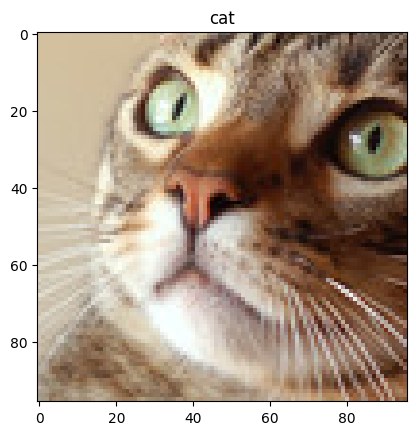

In [241]:
# the image to classify shall look like this image - feel free to change this
img_path = '11.png'
orig_class = 0
orig_name = classnames[orig_class]

orig_img = cv2.imread(img_path)
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB) # cv2 has color order BGR rather than RGB
plt.imshow(orig_img)

plt.title(orig_name);

## Load a Pretrained Image Classification CNN
Define the model that trained in ```cnn-class-cats.ipynb``` and read the parameters from the saved file.

In [242]:
# Hyperparameters
img_size = 96
kernel_size = 3        # equivalent to (3,3)
pool_size = 2          # max pooling size 2x2
first_filters = 32
second_filters = 64
third_filters = 128
dropout_conv = 0.3
dropout_dense = 0.3

# this is the same code as in cnn_class_cats-torch.ipynb
class CNNClassifier(nn.Module):
    def __init__(self, num_classes, img_size):
        super(CNNClassifier, self).__init__()
        # Hardcoded flattened size from previous computation
        flattened_size = 4608  
        self.model = nn.Sequential(
            # Input normalization
            nn.BatchNorm2d(3),
            
            # Block 1
            nn.Conv2d(3, first_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(first_filters, first_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(first_filters, first_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(pool_size),
            nn.Dropout(dropout_conv),
            
            # Block 2
            nn.Conv2d(first_filters, second_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(second_filters, second_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(second_filters, second_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(pool_size),
            nn.Dropout(dropout_conv),
            
            # Block 3
            nn.Conv2d(second_filters, third_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(third_filters, third_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(third_filters, third_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(pool_size),
            nn.Dropout(dropout_conv),
            
            # Classifier block
            nn.Flatten(),
            nn.Linear(flattened_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout_dense),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)


# Create model instance
frozen_model = CNNClassifier(num_classes=K, img_size=img_size)

# Load weights from previous training results
model_save_path = 'animals_and_plants-frozen.pth'
frozen_model.load_state_dict(torch.load(model_save_path))
frozen_model.to(device)
frozen_model.eval()
print(frozen_model)

CNNClassifier(
  (model): Sequential(
    (0): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Dropout(p=0.3, inplace=False)
    (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (12): ReLU()
    (13): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (14): ReLU()
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (16): Dropout(p=0.3, inplace=False)
    (17): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (18): ReLU()
    (19): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
    (20): ReLU()
    (21): Conv2

### Get predictions for the original image
... to verify that the photo is indeed classified as cat.

In [243]:
# convert image to tensor: change from HWC to CHW and scale to [0,1]
x_ = torch.tensor(orig_img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255.0  
x_ = x_.to(device)  # move to device (GPU or CPU), shape (1, 3, 96, 96)

orig_y = frozen_model(x_).squeeze().detach().cpu().numpy()
# apply softmax to get probabilities, remember: torch model outputs logits
orig_y = nn.functional.softmax(torch.tensor(orig_y), dim=0).numpy()

In [244]:
orig_pred_class = orig_y.argmax()
orig_pred_prob = orig_y.max()
print("Probabilities that original image belongs to each of the classes:\n", orig_y)
print("Most likely class is ", orig_pred_class, " = ", classnames[orig_pred_class], " with probability", orig_pred_prob)

Probabilities that original image belongs to each of the classes:
 [9.95961130e-01 1.60083827e-03 2.43395148e-03 3.94983779e-08
 1.95769886e-07 3.88958021e-08 1.47055057e-09 1.16147774e-07
 4.44174120e-09 7.93155493e-07 2.68593823e-07 2.50886978e-06]
Most likely class is  0  =  cat  with probability 0.9959611


So far so good. This just confirms that the loaded model predicts the correct class from this particular cat photo with great confidence. All plant classes are very unlikely.
## Pose the Deception of ```frozen_model``` as an Optimization Problem

In [245]:
target_class = 3 # the modified image should be identified as Maize

In [246]:
def target_fkt(x):
    """The target function to be maximized: The probability of the target class."""
    y = frozen_model(x)
    y = y.squeeze()  # remove batch dimension
    y = nn.functional.softmax(y, dim=0)
    target_prob = y[target_class]
    return target_prob

In [247]:
# try the target function on x, which is currently the original image, but will be changed below.
print ("Target function value for original image:", target_fkt(x_).cpu().detach().numpy().item())

Target function value for original image: 3.9498374349022924e-08


$x$ is far from being identified as a Maize, yet.

### Gradient-based image manipulation
There are several possibilities to change the original image. I suggest the following approach with the code scaffold below.
 1. Compute the gradient, say ```grad```, of ```target_fkt``` with respect to $x$.
 2. Change $x$ in the direction of grad: $x = x + \alpha \cdot \texttt{grad}$.
 3. At the beginning, i.e. when ```x = orig_img```, the gradient has very small entries as the model is amost certain that the image is not of Maize. To make 
 fast progress, choose in each step an $\alpha$ such that the maximal absolute change of a pixel value is ```max_change```.
 3. Observe that the pixel values should be confined to $[0,1]$. 

*Tips:*
 - [torch.abs](https://docs.pytorch.org/docs/stable/generated/torch.abs.html) computes the absolute values
 - [torch.max](https://docs.pytorch.org/docs/stable/generated/torch.max.html) computes a maximum
 - To prevent a division by ```max_grad = 0```, you can use python function `torch.maximum( max_grad, epsilon)` for some small epsilon.
 - [torch.maximum](https://docs.pytorch.org/docs/stable/generated/torch.maximum.html) computes elementwise the larger of two values.
 - [torch.clamp](https://docs.pytorch.org/docs/stable/generated/torch.clamp.html#torch.clamp) can be used to confine the pixel values to $[0,1]$.

However, another approach using a torch optimizer may work as well.

In [248]:
max_iter = 1500
max_change = 0.005     # maximum change per iteration and per pixel
close_enough = False
iter = 0

# create a tensor with gradient tracking
x = x_.clone().requires_grad_(True)


while not close_enough and iter < max_iter:
    # zero previous gradients
    if x.grad is not None:
        x.grad.zero_()
        
    # forward pass and compute target probability
    T = target_fkt(x)
    T.backward()  # compute gradients
    
    grad = x.grad
    max_grad = torch.max(torch.abs(grad))
    alpha = max_change / max(max_grad.item(), 1e-20)  # compute step size safely
    
    if iter < 10 or (iter+1) % 100 == 0:
        print(f"iteration {iter:>3}, optimization target value T = {T.item():.6f}\tmax grad = {max_grad.item():.5f}")
    
    with torch.no_grad():
        x += alpha * grad
        x.clamp_(0, 1)  # ensure pixel values stay within [0,1]
        
    if T.item() > 0.999:
        close_enough = True
        
    iter += 1

iteration   0, optimization target value T = 0.000000	max grad = 0.00000
iteration   1, optimization target value T = 0.000000	max grad = 0.00000
iteration   2, optimization target value T = 0.000001	max grad = 0.00001
iteration   3, optimization target value T = 0.000006	max grad = 0.00005
iteration   4, optimization target value T = 0.000019	max grad = 0.00014
iteration   5, optimization target value T = 0.000043	max grad = 0.00027
iteration   6, optimization target value T = 0.000078	max grad = 0.00042
iteration   7, optimization target value T = 0.000134	max grad = 0.00063
iteration   8, optimization target value T = 0.000231	max grad = 0.00081
iteration   9, optimization target value T = 0.000399	max grad = 0.00120
iteration  99, optimization target value T = 0.101535	max grad = 0.05894
iteration 199, optimization target value T = 0.168891	max grad = 0.03968
iteration 299, optimization target value T = 0.274065	max grad = 0.17501
iteration 399, optimization target value T = 0.5699

#### Check whether the optimization succeeded

In [249]:
with torch.no_grad():
    target_prob = target_fkt(x).item()
print("probability of class", target_class, "is", target_prob)

probability of class 3 is 0.999099850654602


That looks good, but $x$ is not an image in the original format (8 bit integer per color channel). Will the target probability also be large after we made a real image from $x$?

In [250]:
# convert tensor to image: change shape from (1,3,H,W) to (H,W,3), scale to [0,255] and cast to uint8
x_fool = x.detach().squeeze().permute(1, 2, 0).cpu().numpy() * 255.
x_fool = x_fool.astype(np.uint8)

# convert back to tensor format for model input (normalize and add batch dimension)
x_fool_ = torch.tensor(x_fool, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255.
x_fool_ = x_fool_.to(device)  # move to device (GPU or CPU)
with torch.no_grad():
    y_fool = frozen_model(x_fool_).squeeze().detach().cpu().numpy()
    y_fool = nn.functional.softmax(torch.tensor(y_fool), dim=0).numpy()
y_fool_prob = y_fool[target_class]
print("target probability =", y_fool_prob, "\nAll probabilities\n", y_fool)

target probability = 0.99904746 
All probabilities
 [1.8235797e-07 2.7806866e-08 2.0557773e-04 9.9904746e-01 2.2534274e-05
 2.4628533e-05 7.7382896e-07 8.4556697e-05 3.6421021e-08 2.7822146e-08
 4.7261750e-08 6.1418180e-04]


## How much has the image changed?

In [251]:
# maximum and average pixel changes
# first convert images to float tensors and compute the difference
orig_img_tensor = torch.tensor(orig_img, dtype=torch.float32)
x_fool_tensor = torch.tensor(x_fool, dtype=torch.float32)
diff = torch.abs(x_fool_tensor - orig_img_tensor)
max_pixel_change = diff.max().item()
avg_pixel_change = diff.mean().item()
print(f"The maximal total and mean absolute change of a pixel was by {max_pixel_change:.4f} and {avg_pixel_change:.4f}, respectively.")

The maximal total and mean absolute change of a pixel was by 63.0000 and 2.6348, respectively.


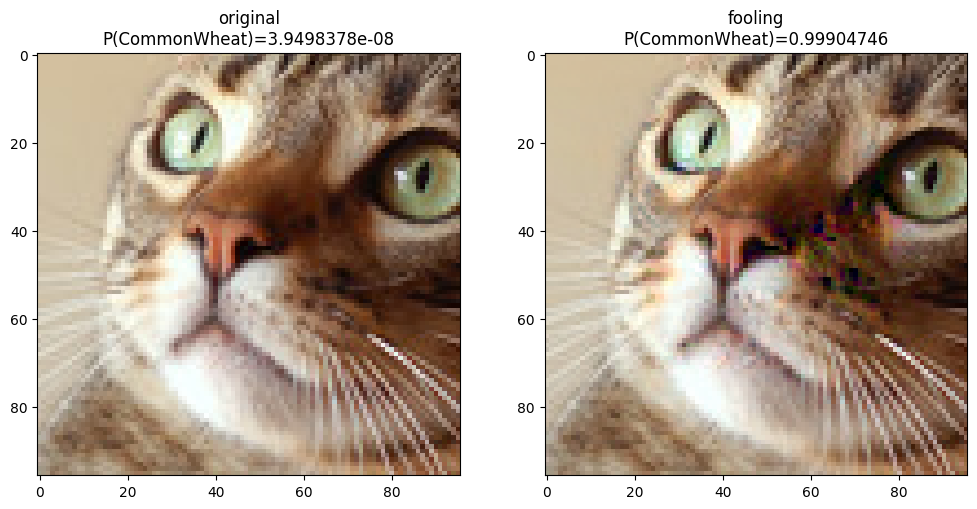

In [252]:
# plot original image and fooling image side by side
_, ax = plt.subplots(1, 2, figsize = (12, 6))
ax[0].imshow(orig_img)
ax[0].set_title("original\nP(" + classnames[target_class] + ")=" + str(orig_y[target_class]));
ax[1].imshow(x_fool)
ax[1].set_title("fooling\nP(" + classnames[target_class] + ")=" + str(y_fool_prob));

0.5941176470588235


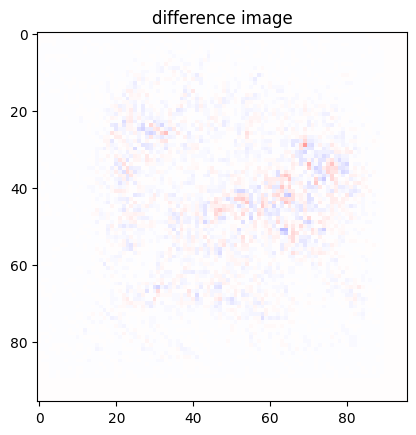

In [258]:
# difference image
diff_img = np.mean((255. + x_fool - orig_img)/2/255, axis = 2) # average over color dimension
print(diff_img.max())
plt.imshow(diff_img, vmin = 0., vmax = 1.,
           cmap = plt.get_cmap('seismic')); # < 0.5 is blue, > 0.5 is red
plt.title("difference image");